# ============================================================
#  WORKBOOK: Physics-Informed Neural Networks (PINNs)
#  Project : Damped Harmonic Oscillator
# ============================================================
#
#  HOW TO USE THIS WORKBOOK
#  ------------------------
#  Each section is a self-contained "chapter". Read the theory
#  block (the big comment), then run the code, then try the
#  exercises at the bottom of each section before moving on.
#
#  REQUIREMENTS:
#    pip install torch numpy matplotlib
#
# ============================================================

# ============================================================
#  CHAPTER 0 — Imports
# ============================================================

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ============================================================
#  CHAPTER 1 — The Physics
# ============================================================
#
#  A mass m on a spring with stiffness k, sliding on a surface
#  with damping coefficient c, obeys Newton's second law:
#
#      m * x''(t) + c * x'(t) + k * x(t) = 0
#
#  where:
#    x(t)  = position at time t
#    x'(t) = velocity  (1st derivative)
#    x''(t)= acceleration (2nd derivative)
#
#  Dividing through by m gives the standard form:
#
#      x'' + (c/m)*x' + (k/m)*x = 0
#
#  We define two shorthand parameters:
#    ω₀ = sqrt(k/m)   → natural frequency (rad/s)
#    ζ  = c/(2*m*ω₀)  → damping ratio (dimensionless)
#
#  The system behaviour depends on ζ:
#    ζ < 1  → underdamped  (oscillates, amplitude decays)  ← we use this
#    ζ = 1  → critically damped (returns to 0 fastest, no oscillation)
#    ζ > 1  → overdamped  (creeps back slowly, no oscillation)
#
#  For the underdamped case the ANALYTICAL solution is:
#
#      x(t) = exp(-ζ*ω₀*t) * [A*cos(ωd*t) + B*sin(ωd*t)]
#
#  where ωd = ω₀ * sqrt(1 - ζ²)  is the damped natural frequency,
#  and A, B are set by initial conditions x(0) and x'(0).

#  ✏️  EXERCISE 1.1
#  ----------------
#  Before running the code below, answer these by hand:
#    a) If m=1, k=4, c=0.4 — what are ω₀ and ζ?
#    b) Is the system underdamped, critically damped, or overdamped?
#    c) What will the position look like over time?
# ============================================================

In [16]:
# --- Physical parameters (feel free to tweak!) ---
m  = 1.0   # kg
k  = 4.0   # N/m
c  = 0.4   # N·s/m

omega0 = np.sqrt(k / m)
zeta   = c / (2 * m * omega0)
omegad = omega0 * np.sqrt(1 - zeta**2)

print("=" * 45)
print("  CHAPTER 1 — System Parameters")
print("=" * 45)
print(f"  Natural frequency  ω₀ = {omega0:.4f} rad/s")
print(f"  Damping ratio      ζ  = {zeta:.4f}")
print(f"  Damped frequency   ωd = {omegad:.4f} rad/s")
if zeta < 1:
    print("  System is: UNDERDAMPED ✓")
elif zeta == 1:
    print("  System is: CRITICALLY DAMPED")
else:
    print("  System is: OVERDAMPED")
print()

  CHAPTER 1 — System Parameters
  Natural frequency  ω₀ = 2.0000 rad/s
  Damping ratio      ζ  = 0.1000
  Damped frequency   ωd = 1.9900 rad/s
  System is: UNDERDAMPED ✓



In [17]:
# --- Initial conditions ---
x0  = 1.0   # initial displacement (m)
v0  = 0.0   # initial velocity    (m/s)

# Solve for A and B from initial conditions:
#   x(0)  = A          → A = x0
#   x'(0) = -ζ*ω₀*A + ωd*B → B = (v0 + ζ*ω₀*x0) / ωd
A = x0
B = (v0 + zeta * omega0 * x0) / omegad

def analytical_solution(t):
    """True solution to the damped harmonic oscillator ODE."""
    return np.exp(-zeta * omega0 * t) * (A * np.cos(omegad * t) + B * np.sin(omegad * t))

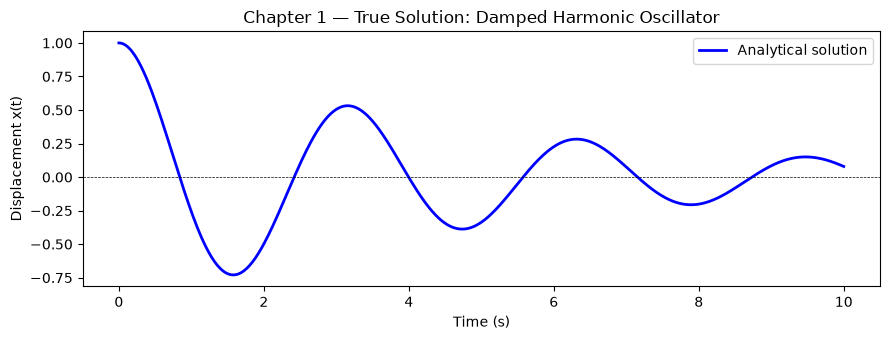

  → Saved: ch1_true_solution.png



In [18]:
# --- Plot the true solution ---
t_plot = np.linspace(0, 10, 500)
x_true = analytical_solution(t_plot)

plt.figure(figsize=(9, 3.5))
plt.plot(t_plot, x_true, 'b', linewidth=2, label='Analytical solution')
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.title("Chapter 1 — True Solution: Damped Harmonic Oscillator")
plt.legend()
plt.tight_layout()
plt.savefig("ch1_true_solution.png", dpi=120)
plt.show()
print("  → Saved: ch1_true_solution.png\n")

# ✏️  EXERCISE 1.2
# ----------------
#  Try changing c to 2.0 (critically damped) and 4.0 (overdamped).
#  Rerun and observe the plots. Change c back to 0.4 before continuing.

# ============================================================
#  CHAPTER 2 — Generating Training Data (Noisy Sensor Data)
# ============================================================
#
#  In a real experiment, sensors measure position with noise.
#  We simulate this by adding Gaussian noise to the true solution
#  at a small number of time points.
#
#  KEY INSIGHT:
#  We deliberately use FEWER data points than we need to uniquely
#  fit the curve. A plain neural net would struggle or overfit.
#  The PHYSICS constraint will save us — stay tuned for Chapter 4.

#  ✏️  EXERCISE 2.1
#  ----------------
#  Before running: how many data points do you think we need to
#  accurately represent 3 full oscillation cycles?  Write your
#  guess here, then see what n_data=8 gets us.
# ============================================================

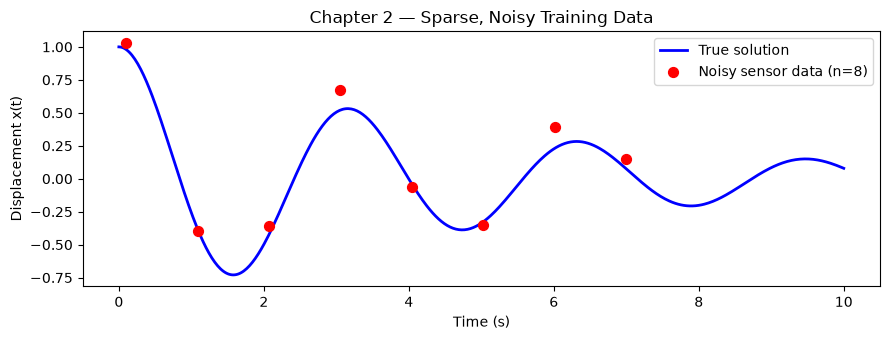

  → Saved: ch2_training_data.png



In [19]:
np.random.seed(42)
torch.manual_seed(42)

n_data      = 8       # number of sensor readings (deliberately sparse!)
noise_level = 0.1     # standard deviation of sensor noise

t_data = np.linspace(0.1, 7.0, n_data)   # sensor times
x_data = analytical_solution(t_data) + noise_level * np.random.randn(n_data)

# Convert to PyTorch tensors (this is what the neural net will consume)
t_data_tensor = torch.tensor(t_data,  dtype=torch.float32).unsqueeze(1)
x_data_tensor = torch.tensor(x_data,  dtype=torch.float32).unsqueeze(1)

plt.figure(figsize=(9, 3.5))
plt.plot(t_plot, x_true, 'b', linewidth=2, label='True solution')
plt.scatter(t_data, x_data, color='red', zorder=5, s=50, label=f'Noisy sensor data (n={n_data})')
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.title("Chapter 2 — Sparse, Noisy Training Data")
plt.legend()
plt.tight_layout()
plt.savefig("ch2_training_data.png", dpi=120)
plt.show()
print("  → Saved: ch2_training_data.png\n")

# ✏️  EXERCISE 2.2
# ----------------
#  Increase n_data to 50 and rerun. Does the scatter look different?
#  Set it back to 8 before Chapter 4.

# ============================================================
#  CHAPTER 3 — Building the Neural Network
# ============================================================
#
#  We build a simple fully-connected network:
#
#      Input: t (scalar time)  →  [hidden layers]  →  Output: x̂(t)
#
#  Architecture:
#    • Input layer  : 1 neuron  (time t)
#    • Hidden layers: 3 layers × 32 neurons each, with Tanh activation
#    • Output layer : 1 neuron  (predicted displacement x̂)
#
#  WHY Tanh?
#  ReLU has zero second derivative almost everywhere, which causes
#  problems when we compute x'' in the physics loss (Chapter 4).
#  Tanh is smooth and differentiable everywhere — perfect for PINNs.

#  ✏️  EXERCISE 3.1
#  ----------------
#  Count the total number of trainable parameters in this network.
#  Formula for a linear layer: (inputs + 1) * outputs
#  Check your answer against the printed output below.
# ============================================================

In [20]:
class PINN(nn.Module):
    def __init__(self, hidden_size=32, n_hidden_layers=3):
        super().__init__()

        # Build layers programmatically
        layers = [nn.Linear(1, hidden_size), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)


model = PINN()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("=" * 45)
print("  CHAPTER 3 — Neural Network")
print("=" * 45)
print(model)
print(f"\n  Total trainable parameters: {total_params}")
print()

  CHAPTER 3 — Neural Network
PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

  Total trainable parameters: 2209



# ✏️  EXERCISE 3.2
# ----------------
#  Try hidden_size=64. Does training (Chapter 5) get better or worse?
#  More parameters doesn't always help — especially with sparse data.

# ============================================================
#  CHAPTER 4 — The Physics Loss (The Heart of PINNs)
# ============================================================
#
#  This is the key idea. Our total loss has TWO terms:
#
#      L_total = L_data + λ * L_physics
#
#  L_data (data loss):
#    Standard MSE between network prediction and sensor measurements.
#    This anchors the network to observed data.
#
#      L_data = (1/N) Σ [x̂(t_i) - x_measured_i]²
#
#  L_physics (physics loss / ODE residual):
#    We sample "collocation points" t_col throughout the domain,
#    compute the ODE residual at each point using AUTOMATIC DIFFERENTIATION,
#    and penalise how much the network violates the ODE.
#
#      residual(t) = m*x̂''(t) + c*x̂'(t) + k*x̂(t)
#      L_physics = (1/N_col) Σ [residual(t_col_i)]²
#
#  If the network perfectly satisfies the ODE, L_physics = 0.
#
#  HOW do we get x̂' and x̂'' from the network?
#    PyTorch's autograd computes exact derivatives of the network
#    output with respect to its input (time t). This is NOT finite
#    differences — it's exact symbolic differentiation through the
#    computation graph. This is what makes PINNs elegant.
#
#  λ (lambda_physics):
#    A weighting hyperparameter balancing the two losses.
#    Too low → network ignores physics.
#    Too high → network ignores data.
#    Typical range: 0.01 – 10. We use 1.0 here.

#  ✏️  EXERCISE 4.1
#  ----------------
#  The residual for a perfect solution should be exactly 0.
#  Why can't a neural network achieve exactly zero physics loss?
# ============================================================

In [21]:
# Collocation points: dense time grid where we enforce the ODE
n_col   = 200
t_col   = torch.linspace(0, 10, n_col, requires_grad=True).unsqueeze(1)

lambda_physics = 1.0   # physics loss weight (try 0.0 in Exercise 5.2!)


def compute_losses(model, t_data_tensor, x_data_tensor, t_col):
    """
    Compute data loss and physics loss.
    Returns: (loss_data, loss_physics, loss_total)
    """

    # ── Data loss ──────────────────────────────────────────
    x_pred_data = model(t_data_tensor)
    loss_data   = torch.mean((x_pred_data - x_data_tensor) ** 2)

    # ── Physics loss ───────────────────────────────────────
    # Forward pass at collocation points
    x_col = model(t_col)                   # shape: (n_col, 1)

    # First derivative: x' = dx/dt  via autograd
    x_col_t = torch.autograd.grad(
        outputs    = x_col,
        inputs     = t_col,
        grad_outputs = torch.ones_like(x_col),
        create_graph = True,               # needed to differentiate again
        retain_graph = True
    )[0]

    # Second derivative: x'' = d²x/dt²
    x_col_tt = torch.autograd.grad(
        outputs    = x_col_t,
        inputs     = t_col,
        grad_outputs = torch.ones_like(x_col_t),
        create_graph = True,
        retain_graph = True
    )[0]

    # ODE residual: m*x'' + c*x' + k*x  (should be 0 everywhere)
    residual = m * x_col_tt + c * x_col_t + k * x_col

    loss_physics = torch.mean(residual ** 2)

    # ── Total loss ─────────────────────────────────────────
    loss_total = loss_data + lambda_physics * loss_physics

    return loss_data, loss_physics, loss_total


print("=" * 45)
print("  CHAPTER 4 — Physics Loss Check")
print("=" * 45)
loss_d, loss_p, loss_t = compute_losses(model, t_data_tensor, x_data_tensor, t_col)
print(f"  (Untrained network)")
print(f"  Data loss    : {loss_d.item():.4f}")
print(f"  Physics loss : {loss_p.item():.4f}")
print(f"  Total loss   : {loss_t.item():.4f}")
print()

  CHAPTER 4 — Physics Loss Check
  (Untrained network)
  Data loss    : 0.2898
  Physics loss : 0.2756
  Total loss   : 0.5654



# ✏️  EXERCISE 4.2
# ----------------
#  Temporarily set lambda_physics = 0.0 and train (Chapter 5).
#  What happens to the prediction outside the data region?
#  This demonstrates WHY the physics term matters.

# ============================================================
#  CHAPTER 5 — Training the PINN
# ============================================================
#
#  We use the Adam optimiser — a popular gradient-descent variant
#  that adapts the learning rate per parameter automatically.
#
#  Training loop:
#    for each epoch:
#      1. Forward pass → predict x̂ at data points and collocation points
#      2. Compute L_data + λ * L_physics
#      3. Backward pass → compute gradients via autograd
#      4. Optimiser step → update network weights
#
#  We train for 5000 epochs. Watch loss_physics drop — that means
#  the network is learning to satisfy the ODE!

#  ✏️  EXERCISE 5.1
#  ----------------
#  What do you expect to see if you plot loss_data and loss_physics
#  vs epoch?  Sketch a rough graph before running.
# ============================================================

In [22]:
model     = PINN()   # fresh model
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 5000
log_every = 500

history = {"epoch": [], "loss_data": [], "loss_physics": [], "loss_total": []}

print("=" * 45)
print("  CHAPTER 5 — Training")
print("=" * 45)
print(f"  {'Epoch':>6}  {'L_data':>10}  {'L_phys':>10}  {'L_total':>10}")
print("  " + "-" * 40)

for epoch in range(1, n_epochs + 1):
    optimiser.zero_grad()
    loss_d, loss_p, loss_t = compute_losses(model, t_data_tensor, x_data_tensor, t_col)
    loss_t.backward()
    optimiser.step()

    if epoch % log_every == 0 or epoch == 1:
        history["epoch"].append(epoch)
        history["loss_data"].append(loss_d.item())
        history["loss_physics"].append(loss_p.item())
        history["loss_total"].append(loss_t.item())
        print(f"  {epoch:>6}  {loss_d.item():>10.5f}  {loss_p.item():>10.5f}  {loss_t.item():>10.5f}")

print()

  CHAPTER 5 — Training
   Epoch      L_data      L_phys     L_total
  ----------------------------------------
       1     0.38475     1.55715     1.94190
     500     0.13058     0.03526     0.16584
    1000     0.05947     0.03614     0.09560
    1500     0.04449     0.03220     0.07669
    2000     0.03759     0.03122     0.06881
    2500     0.02687     0.02678     0.05365
    3000     0.01558     0.01784     0.03341
    3500     0.01042     0.01507     0.02549
    4000     0.00875     0.01369     0.02244
    4500     0.00746     0.01244     0.01989
    5000     0.00671     0.01078     0.01749



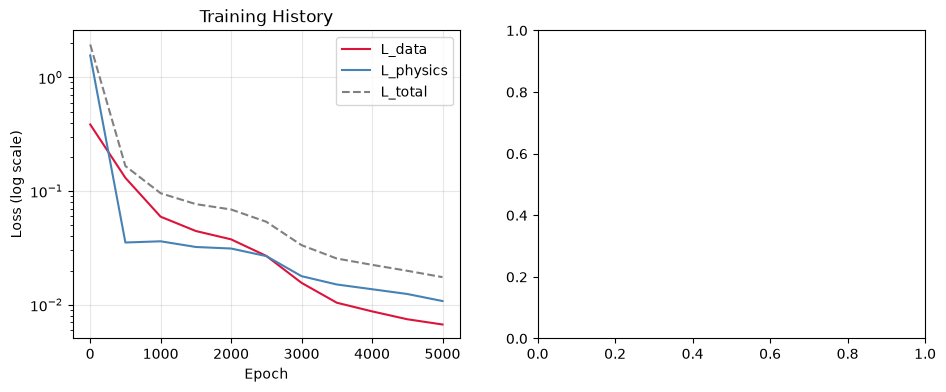

In [23]:
# --- Plot training history ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(history["epoch"], history["loss_data"],    label='L_data',    color='crimson')
axes[0].semilogy(history["epoch"], history["loss_physics"], label='L_physics', color='steelblue')
axes[0].semilogy(history["epoch"], history["loss_total"],   label='L_total',   color='gray', linestyle='--')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log scale)")
axes[0].set_title("Training History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

In [24]:
# --- Plot predictions vs truth ---
t_eval = torch.linspace(0, 10, 500).unsqueeze(1)
with torch.no_grad():
    x_pred = model(t_eval).numpy()

axes[1].plot(t_plot, x_true, 'b', linewidth=2, label='True solution')
axes[1].plot(t_eval.numpy(), x_pred, 'r--', linewidth=2, label='PINN prediction')
axes[1].scatter(t_data, x_data, color='green', zorder=5, s=60, label='Training data')
axes[1].axhline(0, color='k', linewidth=0.5, linestyle='--')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Displacement x(t)")
axes[1].set_title("PINN vs True Solution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ch5_training_results.png", dpi=120)
plt.show()
print("  → Saved: ch5_training_results.png\n")

<Figure size 640x480 with 0 Axes>

  → Saved: ch5_training_results.png



# ✏️  EXERCISE 5.2
# ----------------
#  Set lambda_physics = 0.0 (top of Chapter 4) and retrain.
#  Compare the prediction plot — especially between data points
#  and beyond t=7.  Then restore lambda_physics = 1.0.

# ============================================================
#  CHAPTER 6 — Evaluating the Result
# ============================================================
#
#  A good PINN should:
#    1. Pass through (or near) all data points
#    2. Match the true solution even WHERE THERE IS NO DATA
#    3. Show a smooth, physically meaningful curve
#
#  We quantify this with the relative L2 error:
#
#      error = ||x_true - x_pred||_2 / ||x_true||_2
#
#  A value below 0.01 (1%) is excellent for a sparse-data PINN.

#  ✏️  EXERCISE 6.1
#  ----------------
#  The network never saw the true solution — only 8 noisy points.
#  How does it "know" the shape of the solution between/beyond
#  the data points?  Write a 2-sentence explanation.
# ============================================================

In [25]:
t_eval_np = t_eval.numpy().flatten()
x_pred_np = x_pred.flatten()
x_true_eval = analytical_solution(t_eval_np)

relative_l2 = np.linalg.norm(x_true_eval - x_pred_np) / np.linalg.norm(x_true_eval)
max_abs_err  = np.max(np.abs(x_true_eval - x_pred_np))

print("=" * 45)
print("  CHAPTER 6 — Evaluation Metrics")
print("=" * 45)
print(f"  Relative L2 error : {relative_l2:.4f}  ({relative_l2*100:.2f}%)")
print(f"  Max absolute error: {max_abs_err:.4f} m")
print()

  CHAPTER 6 — Evaluation Metrics
  Relative L2 error : 0.1461  (14.61%)
  Max absolute error: 0.1407 m



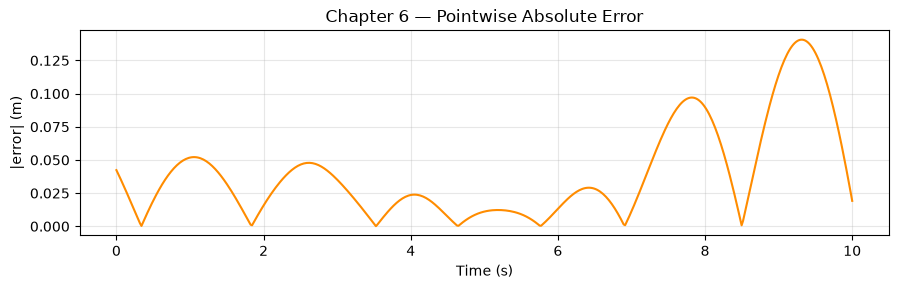

  → Saved: ch6_error_plot.png



In [26]:
# --- Error plot ---
plt.figure(figsize=(9, 3))
plt.plot(t_eval_np, np.abs(x_true_eval - x_pred_np), color='darkorange', linewidth=1.5)
plt.xlabel("Time (s)")
plt.ylabel("|error| (m)")
plt.title("Chapter 6 — Pointwise Absolute Error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ch6_error_plot.png", dpi=120)
plt.show()
print("  → Saved: ch6_error_plot.png\n")

# ✏️  EXERCISE 6.2
# ----------------
#  Increase n_data (Chapter 2) from 8 to 20. Does the error drop?
#  By how much?  Is the physics loss still needed?

# ============================================================
#  CHAPTER 7 — Ablation Study: Physics ON vs OFF
# ============================================================
#
#  An "ablation study" removes one component to measure its effect.
#  Here we train TWO models side by side:
#    • Model A: data loss only  (plain neural net, λ=0)
#    • Model B: data + physics  (full PINN,       λ=1)
#
#  This directly shows the VALUE of the physics constraint.

#  ✏️  EXERCISE 7.1
#  ----------------
#  Before running, predict:
#    a) Which model will be better BETWEEN data points?
#    b) Which model will be better BEYOND t=7 (extrapolation region)?
# ============================================================

  CHAPTER 7 — Ablation Study
  Training Model A (no physics)...
  Training Model B (with physics)...
  Done!



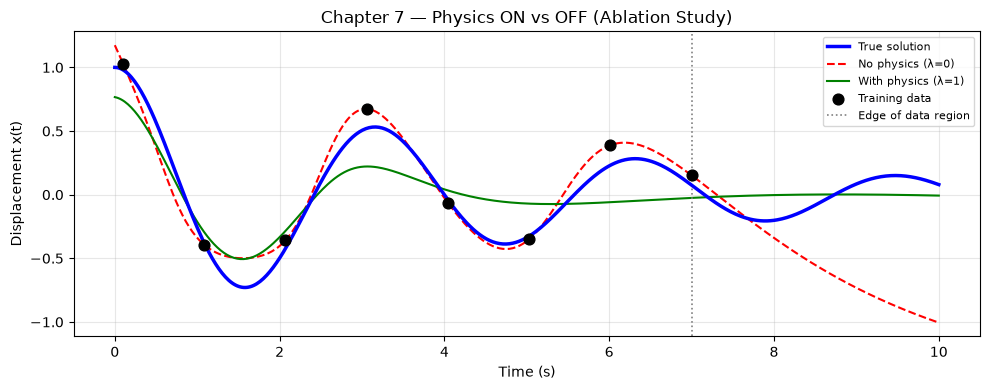

  → Saved: ch7_ablation.png



In [27]:
def train_model(lambda_phys, n_epochs=5000):
    """Train a PINN with a given physics loss weight."""
    net = PINN()
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    for _ in range(n_epochs):
        opt.zero_grad()
        x_p = net(t_data_tensor)
        ld  = torch.mean((x_p - x_data_tensor) ** 2)

        if lambda_phys > 0:
            x_c = net(t_col)
            xct = torch.autograd.grad(x_c, t_col, torch.ones_like(x_c),
                                       create_graph=True, retain_graph=True)[0]
            xctt = torch.autograd.grad(xct, t_col, torch.ones_like(xct),
                                        create_graph=True, retain_graph=True)[0]
            res = m * xctt + c * xct + k * x_c
            lp  = torch.mean(res ** 2)
        else:
            lp = torch.tensor(0.0)

        loss = ld + lambda_phys * lp
        loss.backward()
        opt.step()
    return net

print("=" * 45)
print("  CHAPTER 7 — Ablation Study")
print("=" * 45)
print("  Training Model A (no physics)...")
model_no_phys = train_model(lambda_phys=0.0)
print("  Training Model B (with physics)...")
model_phys    = train_model(lambda_phys=1.0)
print("  Done!\n")

with torch.no_grad():
    pred_no_phys = model_no_phys(t_eval).numpy()
    pred_phys    = model_phys(t_eval).numpy()

plt.figure(figsize=(10, 4))
plt.plot(t_plot,        x_true,                   'b',   linewidth=2.5, label='True solution',         zorder=3)
plt.plot(t_eval.numpy(), pred_no_phys,             'r--', linewidth=1.5, label='No physics (λ=0)',      zorder=2)
plt.plot(t_eval.numpy(), pred_phys,                'g-',  linewidth=1.5, label='With physics (λ=1)',    zorder=2)
plt.scatter(t_data, x_data, color='k', zorder=5, s=60, label='Training data')
plt.axvline(x=7.0, color='gray', linestyle=':', linewidth=1.2, label='Edge of data region')
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.title("Chapter 7 — Physics ON vs OFF (Ablation Study)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ch7_ablation.png", dpi=120)
plt.show()
print("  → Saved: ch7_ablation.png\n")

# ✏️  EXERCISE 7.2 (Capstone)
# ----------------------------
#  Now adapt this project to a SIMPLE PENDULUM.
#  The ODE is:   θ'' + (g/L)*sin(θ) = 0   (nonlinear!)
#  For small angles, sin(θ) ≈ θ, giving θ'' + (g/L)*θ = 0
#
#  Steps:
#    1. Change the analytical solution to the pendulum formula
#    2. Change the ODE residual in compute_losses()
#    3. Choose parameters: g=9.81, L=1.0
#    4. Train and compare. Does the PINN still work?

# ============================================================
#  CHAPTER 8 — Summary and What's Next
# ============================================================
#
#  You've built a real PINN! Here's what you learned:
#
#  ✅  The physics of a damped harmonic oscillator (ODE, ζ, ω₀)
#  ✅  How to generate and work with noisy sparse sensor data
#  ✅  How PyTorch's autograd computes exact derivatives of a network
#  ✅  The two-term PINN loss: L_data + λ * L_physics
#  ✅  Why the physics constraint enables better extrapolation
#  ✅  How to measure and plot prediction error
#  ✅  What an ablation study is and how to run one
#
#  NEXT STEPS (in order of difficulty):
#  ─────────────────────────────────────
#  1. Nonlinear pendulum (Exercise 7.2 above)
#  2. 2D problem: two coupled oscillators (2 ODEs)
#  3. 1D heat equation (a PDE instead of an ODE)
#  4. Inverse problem: learn k or c from data instead of x(t)
#  5. ⭐ Two-body orbital mechanics (Newton's law of gravitation)
#       — same PINN framework, gorgeous orbital trajectory outputs
#
#  KEY PAPERS to read when you're ready:
#  ──────────────────────────────────────
#  • Raissi et al. (2019) "Physics-informed neural networks"
#    Journal of Computational Physics — the original PINN paper
#  • Lagaris et al. (1998) — the earlier precursor
#
# ============================================================

In [28]:
print("=" * 45)
print("  ALL CHAPTERS COMPLETE!")
print("=" * 45)
print()
print("  Output files generated:")
print("    ch1_true_solution.png")
print("    ch2_training_data.png")
print("    ch5_training_results.png")
print("    ch6_error_plot.png")
print("    ch7_ablation.png")
print()
print("  Work through the ✏️ exercises, then tackle")
print("  the capstone in Exercise 7.2 — good luck!")
print("=" * 45)

  ALL CHAPTERS COMPLETE!

  Output files generated:
    ch1_true_solution.png
    ch2_training_data.png
    ch5_training_results.png
    ch6_error_plot.png
    ch7_ablation.png

  Work through the ✏️ exercises, then tackle
  the capstone in Exercise 7.2 — good luck!
